# Advanced GLAES Workflow Examples

This notebook introduces several practical GLAES features that build on the basic workflow.
It is intended for users who already understand how to create an `ExclusionCalculator`
and want to explore additional exclusion methods, visualization options, and raster handling.

### Overview:
1. How to apply exclusion rules from a table using `exclusion_set`
2. How to restart from a precomputed result
3. How to visualize results with and without basemaps
4. How to inspect region grid properties
5. Why `padExtent` matters near borders
6. How to use `excludeRasterType` with value ranges
7. How to use inclusion mode and inversion
8. How to work with DEM mosaics for elevation and slope exclusions
9. Working with `excludeVectorType()`
10. Visualization methods

In [37]:
import glaes as gl
import geokit as gk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
# Use built-in test data so the examples run without extra downloads
region_path = gl._test_data_["aachenShapefile.shp"]
clc_path = gl._test_data_["clc-aachen_clipped.tif"]

# Create a standard exclusion calculator used in several examples
ec = gl.ExclusionCalculator(region_path, srs=3035, pixelRes=100)

# 1. Working with Exclusion Sets
Instead of calling several exclusion functions one by one, you can define exclusion rules
in a table and apply them in a single step.
In this example, a sample exclusion table is loaded from the built-in GLAES test data.

In [39]:
exclusion_set = pd.read_csv(gl._test_data_["sample_exclusion_set.csv"])
exclusion_set

,name,type,value,buffer
0,clc,raster,[12-22],NaN
1,clc,raster,[1-2],1000.0
2,osm_roads,vector,type='motorway' OR type='primary' OR type='trunk',200.0


Excluding Raster clc with value [12-22], buffer None, mode exclude, and invert False
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 403.25 MB


Excluding Raster clc with value [1-2], buffer 1000.0, mode exclude, and invert False


Memory useage during calc: 405.22265625 MB


Excluding Vector osm_roads with where-statement "type='motorway' OR type='primary' OR type='trunk'", buffer 200.0, mode exclude, and invert False 
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


Memory useage during calc: 419.16796875 MB


Done!


<Axes: >

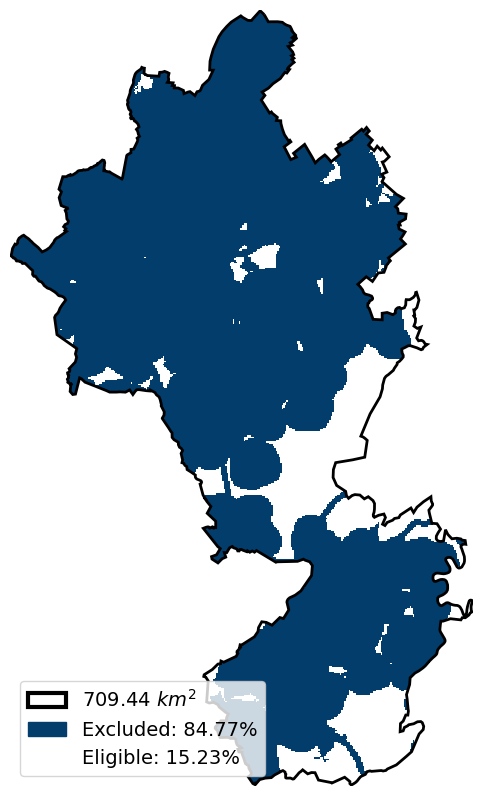

In [40]:
# Start with a new ExclusionCalculator for this example.
ec = gl.ExclusionCalculator(region_path, srs=3035, pixelRes=100)

# Apply all exclusion rules listed in the table. 
# The additional keyword arguments provide the datasets referenced inside the table.
ec.excludeSet(
    exclusion_set=exclusion_set,
    clc=gl._test_data_["clc-aachen_clipped.tif"],
    osm_roads=gl._test_data_["aachenRoads.shp"],
)

ec.draw()

# 2. Reinitialize an ExclusionCalculator from a pre-computed result
If a previous exclusion result has already been saved as a raster, you can use it as the
starting point for a new `ExclusionCalculator`.

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 417.515625 MB


<Axes: >

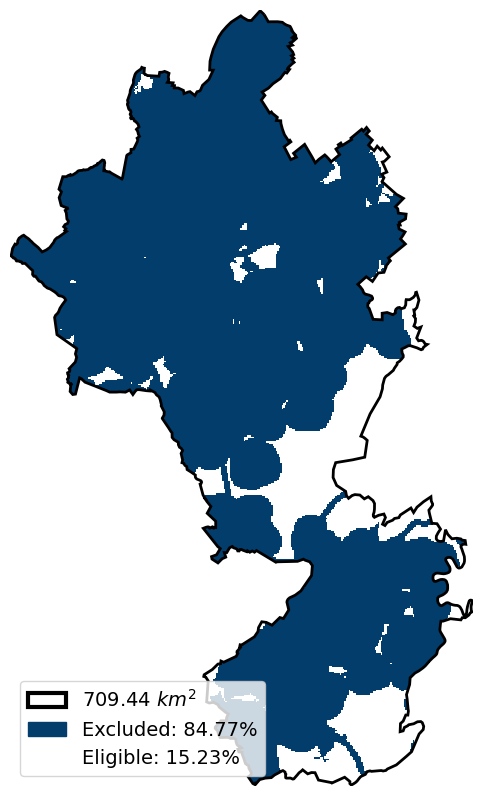

In [41]:
## Set the initial value to those we computed previously. This is particularly useful if the original calculation took a while
ec = gl.ExclusionCalculator(
    region_path,
    srs=3035,
    pixelRes=100,
    initialValue="data/aachens_best_pv_spots.tif",
)

ec.draw()

# 3. Draw exclusions with a basemap

In addition to the standard plot, GLAES can draw results on top of a basemap.
This can make it easier to understand where exclusions are located in real space. Keep the zoom level moderate to avoid slow loading.

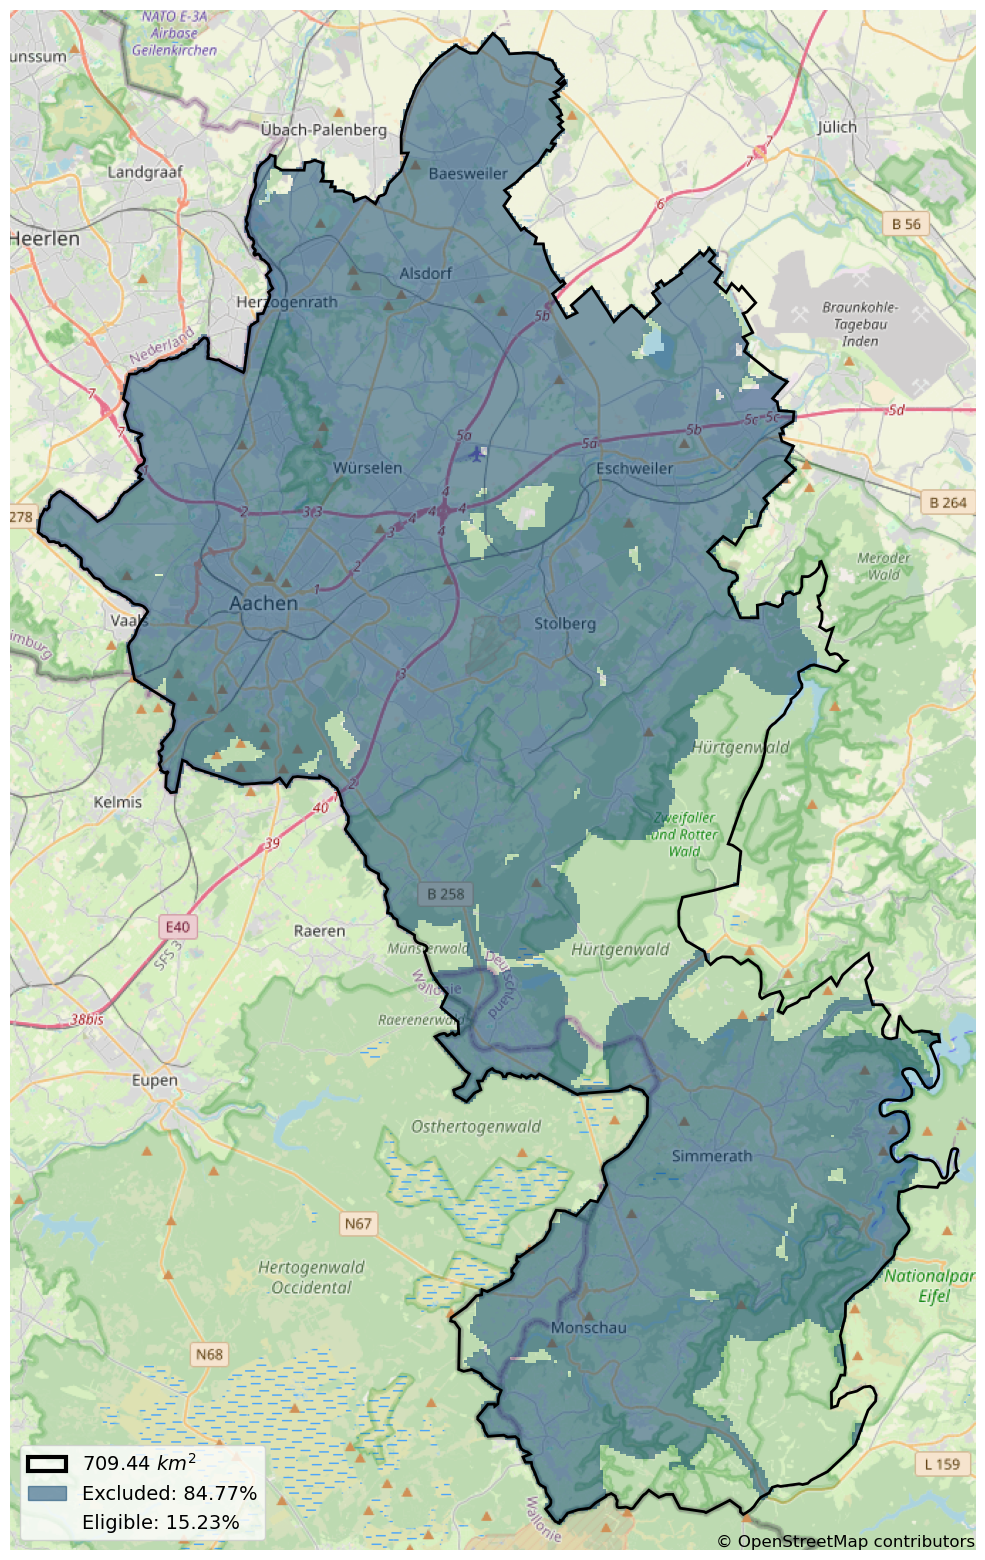

In [42]:
ax = ec.drawWithSmopyBasemap(zoom=11, figsize=(40, 20))

# 4. Inspect region grid information

Each `ExclusionCalculator` works on a raster grid defined by the region, spatial reference
system, and pixel resolution.

Understanding this grid is useful because it helps you see:

- the spatial extent being processed
- the raster mask used internally
- the size of the calculation grid

In [43]:
# Create a fresh ExclusionCalculator so the grid properties are easy to inspect.
ec = gl.ExclusionCalculator(region_path, srs=3035, pixelRes=100)
# The bounding box around the region, expressed in the chosen coordinate system.
ec.region.extent

xMin: 4037300.000000
xMax: 4067700.000000
yMin: 3049300.000000
yMax: 3100200.000000
srs: PROJCS["ETRS89-extended / LAEA Europe",GEOGCS["ETRS89",DATUM["European_Terrestrial_Reference_System_1989",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6258"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4258"]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",4321000],PARAMETER["false_northing",3210000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Northing",NORTH],AXIS["Easting",EAST],AUTHORITY["EPSG","3035"]]

In [44]:
# Mask: Pixel grid inside bounding box, according to pixelRes (True = inside regiion, False = outside region)
ec.region.mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [45]:
# The shape of the internal grid as (rows, columns).
ec.region.mask.shape

(509, 304)

# 5. Considering region boundary effects with padExtent 
Some exclusions (for example buffers around roads or settlements) depend on features that may
lie just outside the region boundary.

If you do *not* include a padding area around the region, then:

- buffers can get cut off at the boundary
- exclusions near the border may be underestimated

`padExtent` adds a buffer (in meters, in the calculator's SRS units) around the region's
bounding box *for processing*, while the final availability is still evaluated for the region.

Below we compare the region grid with and without padding.

In [46]:
# No padding: the grid covers only the region bounding box.
ec0 = gl.ExclusionCalculator(
    region=region_path,
    srs=3035,
    pixelRes=100,
    padExtent=0,
)

print("Extent (padExtent=0):", ec0.region.extent)
print("Mask shape (padExtent=0):", ec0.region.mask.shape)

Extent (padExtent=0): (4037300.00000,3049300.00000,4067700.00000,3100200.00000)
Mask shape (padExtent=0): (509, 304)


In [47]:
# With padding: the grid is expanded, which helps compute exclusions near the region border correctly.
ec_pad = gl.ExclusionCalculator(
    region=region_path,
    srs=3035,
    pixelRes=100,
    padExtent=2000,  # 2 km padding around the region bounding box
)

print("Extent (padExtent=2000):", ec_pad.region.extent)
print("Mask shape (padExtent=2000):", ec_pad.region.mask.shape)

Extent (padExtent=2000): (4035300.00000,3047300.00000,4069700.00000,3102200.00000)
Mask shape (padExtent=2000): (549, 344)


Note that
- `xMin` and `yMin` become **smaller**
- `xMax` and `yMax` become **larger**

So the box grows outward in every direction, which is why the grid shape also increases.

# 6. excludeRasterType with ranges for clc classes
`excludeRasterType` can exclude raster cells based on selected values.
For categorical rasters such as CORINE Land Cover (CLC), this lets you exclude several classes at once.

Instead of listing every value separately, you can also use compact range syntax.

In the example below:

- `[1-2]` selects all classes from 1 to 2
- `12` selects class 12
- `[21-23]` selects all classes from 21 to 23

This is useful when you want to exclude multiple related land cover classes in one step.

Memory useage during calc: 471.25 MB


<Axes: >

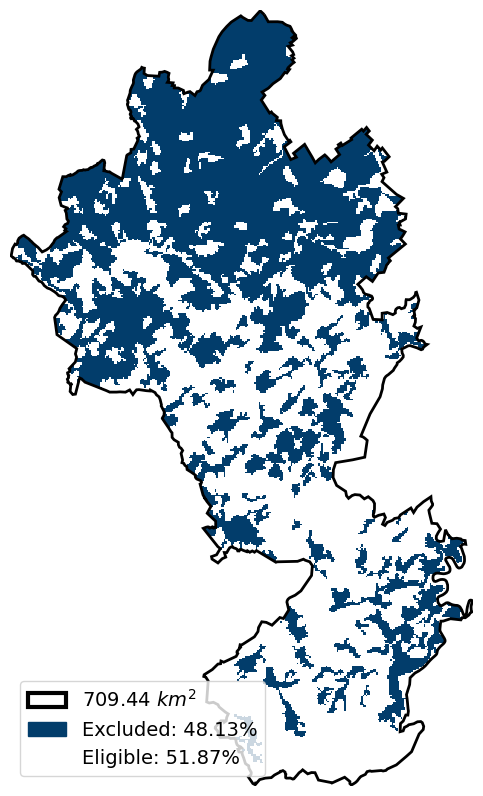

In [48]:
ec = gl.ExclusionCalculator(region_path, srs=3035, pixelRes=100)

ec.excludeRasterType(
    source=clc_path,
    value="[1-2],12,[21-23]",
)

ec.draw()

# 7. Alternative exclusion approaches (include, invert, initialValue)

By default, a new `ExclusionCalculator` starts with all cells inside the region marked as eligible.

You can change this starting state with `initialValue`:

- the default behavior starts with all cells available
- `initialValue=False` starts with all cells unavailable

This is useful when you want to build suitability from the ground up by explicitly including only selected areas.

Two related options in `excludeRasterType` are:

- `mode="include"`: keep only the selected values as eligible
- `invert=True`: reverse the selection before applying the exclusion

To make this easier to understand, both examples below use the same land cover classes:

- `[1-2]`
- `12`
- `[21-23]`

Memory useage during calc: 436.45703125 MB
Percent available with include mode: 48.132329724853406


<Axes: >

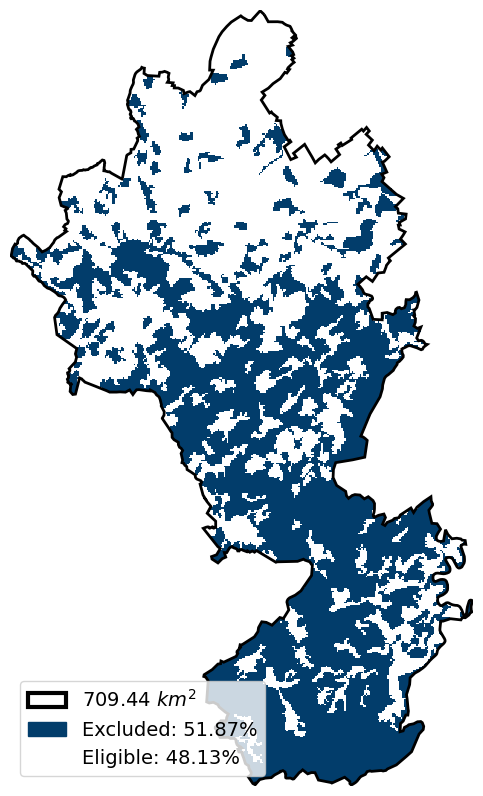

In [49]:
# Start with everything unavailable.
ec = gl.ExclusionCalculator(
    region=region_path,
    srs=3035,
    pixelRes=100,
    initialValue=False,
)

# Include only the selected land cover classes.
ec.excludeRasterType(
    source=clc_path,
    value="[1-2],12,[21-23]",
    mode="include",
)

print("Percent available with include mode:", ec.percentAvailable)
ec.draw()

Memory useage during calc: 438.546875 MB
Percent available with invert=True: 48.132329724853406


<Axes: >

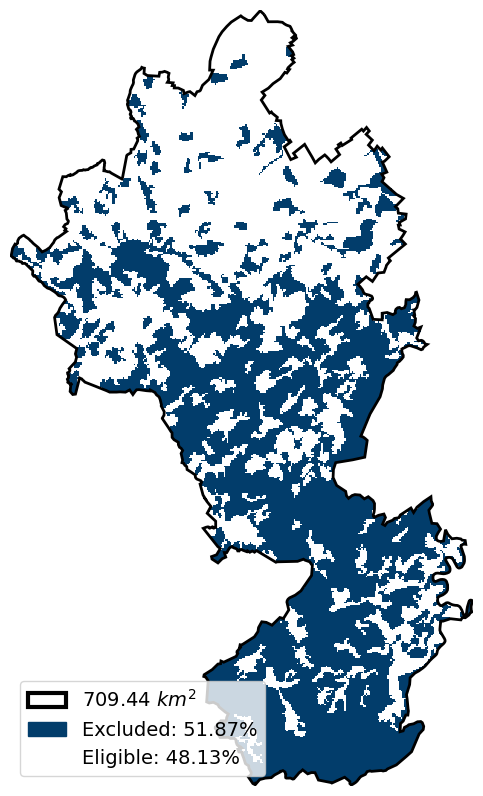

In [50]:
# Start with everything available.
ec = gl.ExclusionCalculator(
    region=region_path,
    srs=3035,
    pixelRes=100,
)

# Invert the selection, then exclude it.
# This excludes all cells NOT in the selected classes,
# so only the same selected classes remain eligible.
ec.excludeRasterType(
    source=clc_path,
    value="[1-2],12,[21-23]",
    invert=True,
)

print("Percent available with invert=True:", ec.percentAvailable)
ec.draw()

**Why do these look similar?**  
Both examples keep the same classes as eligible, but they start from different initial states:

- In the `mode="include"` example, `initialValue=False` means all cells start as unavailable, and only the selected classes are added as eligible.
- In the `invert=True` example, the default initial state means all cells start as available, and then everything except the selected classes is excluded.

# 8. Working with DEM Mosaics to exclude Raster
By default, DEM data is often distributed as separate raster tiles. A **Digital Elevation Model (DEM)** is a raster dataset in which each pixel stores the ground elevation at that location.

If a study area covers multiple DEM tiles, they can be merged into a single raster with `rasterMosaic()`.

This is useful when you want to create one continuous elevation layer for the full region.

In the example below:

- `.hgt` files are used as DEM inputs
- all matching files are merged into one raster mosaic
- the mosaic is displayed with `gk.drawRaster()` as an elevation heatmap

DEM data for other regions can be downloaded from:

- `https://dwtkns.com/srtm30m`  

<class 'osgeo.gdal.Dataset'>


AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x00000148BACF5390>, cbar=<matplotlib.colorbar.Colorbar object at 0x00000148BC505F90>)

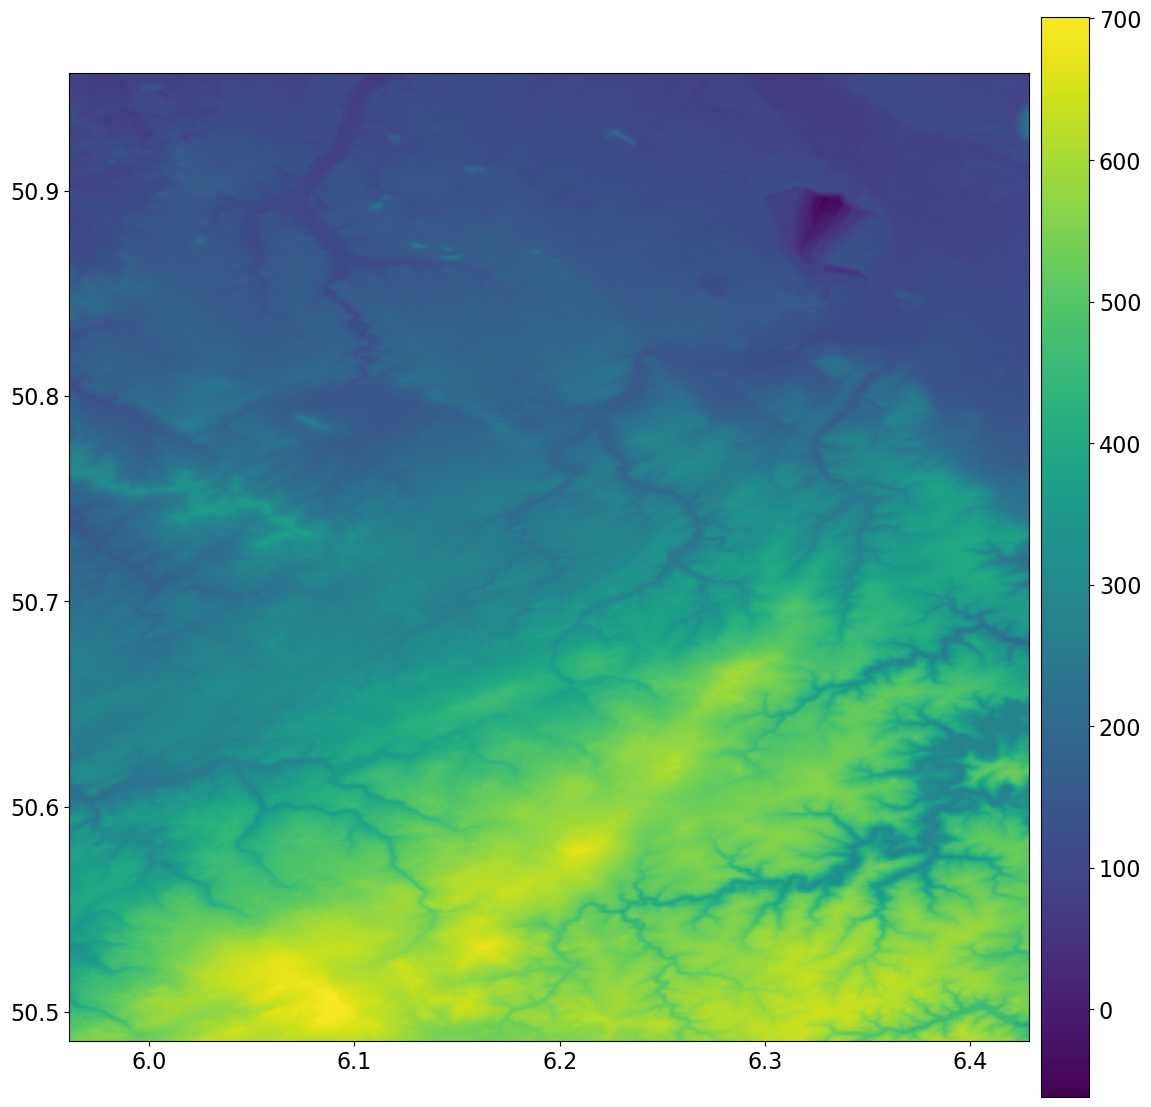

In [51]:
import geokit as gk

dem_raster = ec.region.extent.rasterMosaic(r"../glaes/test/data/*.hgt")
print(type(dem_raster)) # multiple DEM files merged into a single raster mosaic
gk.drawRaster(dem_raster)

Memory useage during calc: 483.51171875 MB


<Axes: >

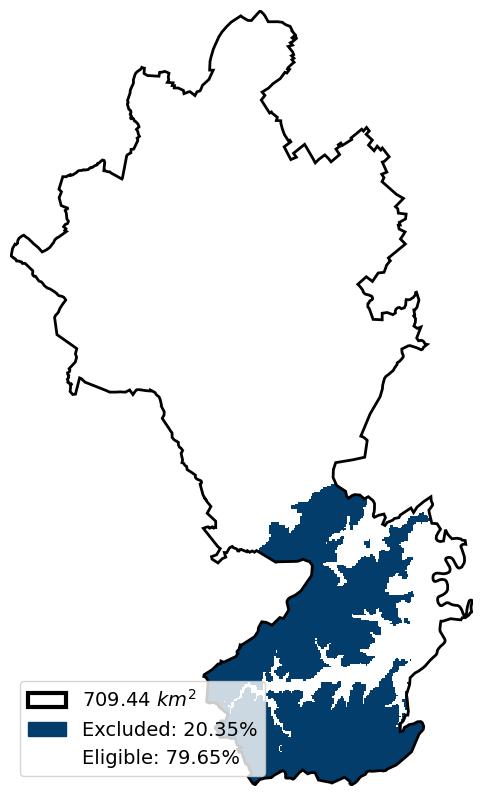

In [52]:
# exclude areas above 500m elevation. Note, that here the hilly Eiffel region is mainly exluded in the region's south.
ec = gl.ExclusionCalculator(region_path, srs=3035, pixelRes=100)
ec.excludeRasterType(dem_raster, value="(500-]", resampleAlg="mode")
ec.draw()

Memory useage during calc: 477.26953125 MB


<Axes: >

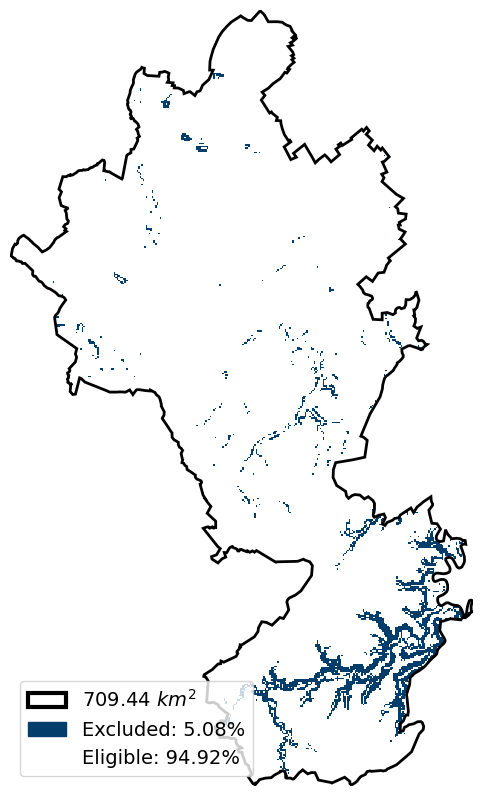

In [ ]:
# Exclude Raster - DEM Gradient Mosaic. Exlude slopes above 15 degrees.

dem_gradient_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(                          # computes the gradient (slope) of a raster
            source=dem_raster,
            factor="latlonToM"),                        # factor to convert lat/lon degrees to meters
    processor=lambda x: np.degrees(np.arctan(x))        # convert gradient to degrees
)

ec = gl.ExclusionCalculator(region_path, srs=3035, pixelRes=100)
ec.excludeRasterType(dem_gradient_raster, value=(15, None), resampleAlg="mode")

ec.draw()

Memory useage during calc: 475.55078125 MB


<Axes: >

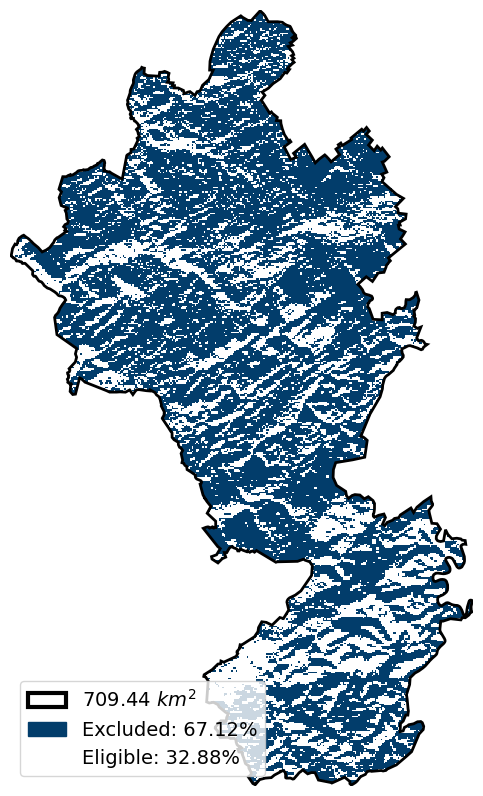

In [ ]:
# Exlude slopes with north orientation, as north facing slopes receive less radiation.

dem_ns_gradient_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(
            source=dem_raster,
            factor="latlonToM",
            mode="north-south"),
    processor=lambda matrix: np.degrees(np.arctan(matrix))
)

ec = gl.ExclusionCalculator(region_path, srs=3035, pixelRes=100)

# exclude all north facing slopes (values > 0 degrees)
ec.excludeRasterType(dem_ns_gradient_raster, value=(0, None), resampleAlg="mode")

ec.draw()

# 9. ExcludeVectorType
This section shows how `excludeVectorType()` can be used to exclude areas from vector datasets.

Use where clause to exclude IUCN_CAT='V' (IUCN protected area management category, category V: Protected Landscape):

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


<Axes: >

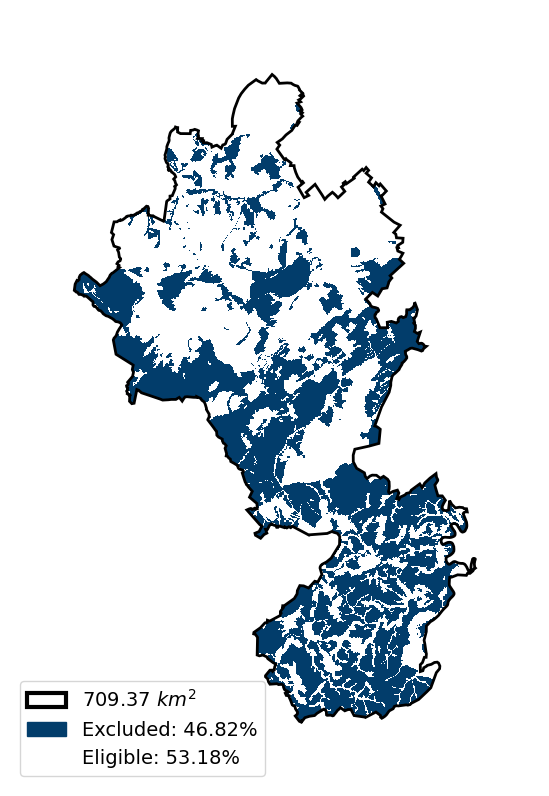

In [72]:
#  Exclude Vector - Simple source w/ where clause

ec = gl.ExclusionCalculator(
    region=gk._test_data_['aachenShapefile.shp'],
    srs="LAEA", 
    pixelRes=50,
    padExtent=5000)

ec.excludeVectorType(
    source=r"data/WDPA_aachen_bbox.shp",
    where="IUCN_CAT='V'",
)

ec.draw()

The following example uses `resolutionDiv` to rasterize vector features at a finer internal resolution.

Applying intermediate exclusion file: intermediate_files/wdpa_V.tif


<Axes: >

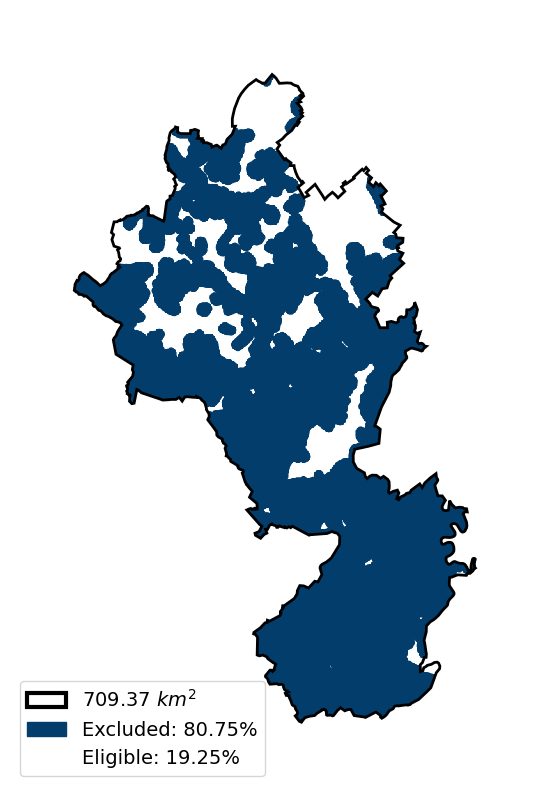

In [ ]:
# Exclude Vector - resolutionDiv
ec = gl.ExclusionCalculator(
    region=gk._test_data_['aachenShapefile.shp'],
    srs="LAEA", 
    pixelRes=50,
    padExtent=5000)

ec.excludeVectorType(
    source=r"data/WDPA_aachen_bbox.shp",
    where="IUCN_CAT='V'",
    buffer=400,
    resolutionDiv=8,
    intermediate="intermediate_files/wdpa_V.tif"
)
ec.draw()

In [62]:
ec.save?

Signature: ec.save(output, threshold=None, **kwargs)
Docstring:
Save the current availability matrix to a raster file

Output will be a byte-valued raster with the following convention:
    0     -> unavailable
    1..99 -> Semi-available
    100   -> fully eligibile
    255   -> "no data" (out of region)

Parameters:
-----------
output : str
    The path of the output raster file
    * Must end in ".tif"

threshold : float; optional
    The acceptable threshold indicating an available pixel
    * Use this to process the availability matrix before saving it (will
      save a little bit of space)

kwargs:
    * All keyword arguments are passed on to a call to
      geokit.RegionMask.createRaster
    * Most notably:
        - 'dtype' is used to define the data type of the resulting raster
        - 'overwrite' is used to force overwrite an existing file
File:      c:\users\j.mutke\appdata\local\miniforge3\envs\glaes\lib\site-packages\glaes\core\exclusioncalculator.py
Type:      method

In [63]:
ec.save("tmp/test_resolution_div_8.tif")

'tmp/test_resolution_div_8.tif'

# 10 Visualization Methods

<Axes: >

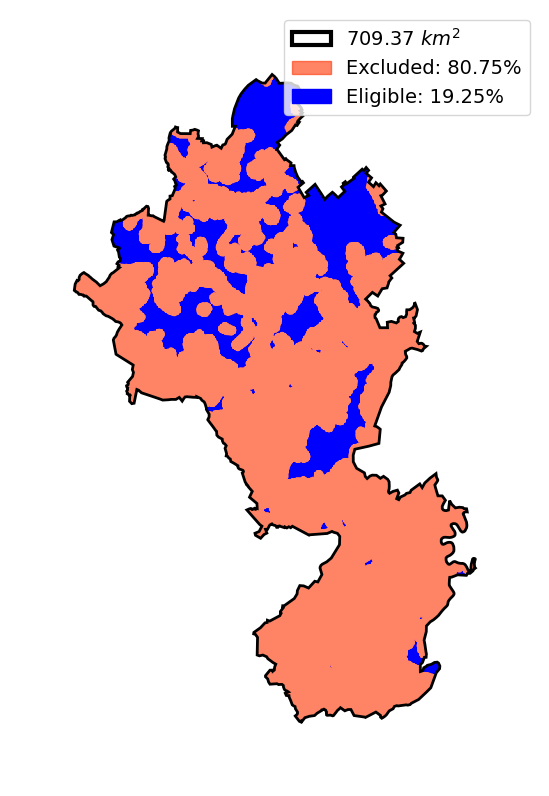

In [ ]:
# regular drawing with custom colors and legend position
ec.draw(
    goodColor="blue",
    excludedColor=(1.0, 0.2, 0.0, 0.6),
    legendargs={'loc': 'upper right'},)

Additional spatial layers can also be drawn on top of the exclusion result.
In the example below, major roads are added as a vector overlay.

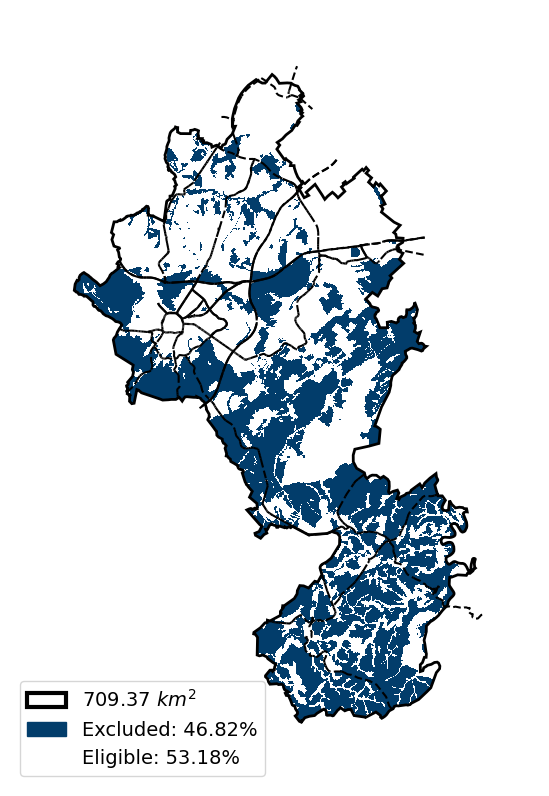

In [68]:
ax = ec.draw()
roads = gk.vector.extractFeatures(r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/glaes/test/data/aachenRoads.shp", 
                                  where="type='motorway' OR type='primary' OR type='trunk'",
                                  geom=ec.region.geometry)
gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=ec.region.srs)
plt.show()

In [69]:
roads.type.unique()

array(['primary', 'motorway'], dtype=object)

`drawWithSmopyBasemap()` can be used to display exclusion results on top of a map background.

This is useful when the result should be interpreted in its geographic context, for example to compare excluded areas with roads, settlements, or other recognizable landscape features.

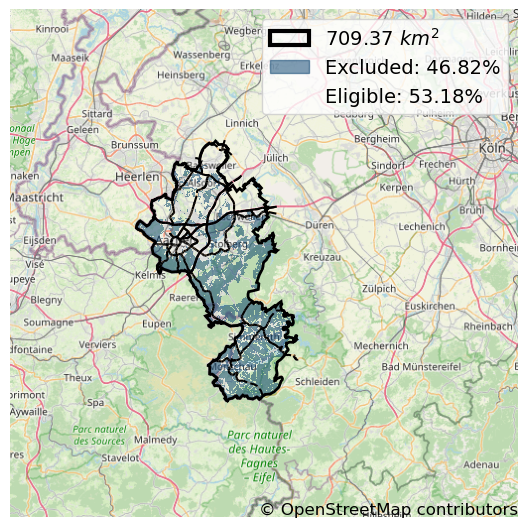

In [70]:
ax = ec.drawWithSmopyBasemap(
    zoom=9,
    legendargs={'loc': 'upper right'},)
gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=gk.srs.EPSG3857)
plt.show()

In [71]:
ec.drawWithSmopyBasemap?

Signature:
ec.drawWithSmopyBasemap(
    zoom=4,
    excludedColor=(0.00784313725490196, 0.23921568627450981, 0.4196078431372549, 0.5019607843137255),
    ax=None,
    figsize=None,
    smopy_kwargs={'attribution': '© OpenStreetMap contributors', 'attribution_size': 12},
    **kwargs,
)
Docstring:
This wrapper around the original ExclusionCalculator.draw function adds a basemap bethind the drawn eligibility map

NOTE:
* The basemap is drawn using the Smopy python package. See here: https://github.com/rossant/smopy
* Be careful to adhere to the usage guidelines of the chosen tile source
    - By default, this source is OSM. See here: https://wiki.openstreetmap.org/wiki/Tile_servers

!IMPORTANT! If you will publish any images drawn with this method, it's likely that the tile source
will require an attribution to be written on the image. For example, if using OSM tile (the default),
you have to write "© OpenStreetMap contributors" clearly on the map. But this is different for each
tile sou

# Miscellaneous

# TO DO

NEXT: continue commenting and cleaning up at section 8. DEM mosaics

- doublecheck remaining functions in the workshopfile to be added (only placement in the very bottom should be missing, and is not running due to Prior dataset issues)
- workaround to be fixed: asArea=True doenst work (cf. 01_placement file) - - workaround for ec.distributeItems( separation=1000, asArea=True)
- Finalize short introduction  

? MIssing Data files:    
    ? gwa3_250_wind-speed_100m.NRW.tif" # shared data cluster
    ? axialDirection=f(ERA5_wind_direction_100m_mean.tiff) # gk, clipping
    ? is temp directory actually ingoing data? If yes, then merge into /data
    ? ensure relative paths only
    ? Cut WDPA_Jul2020-shapefile-polygons.shp (4 GB alternative) [JM] got them from Julia (check Reskit comment from Chris)

? srs = LAEA vs 3035 ? [@chris]d

@others
- finished clean up for methods_2

In [69]:
# Exclude Raster - resolutionDiv
# Exclude Raster - prewarp
# Exclude Raster - resampleAlg -> "Down sampling": near,bilinear,cubic  "upsampling":average,mode,max,min

# placement stuff to be added? Last section from workshop file..

In [70]:
# # Clip WDPA files smaller with geokit

# # Check WDPA Ausdehnung. Man sieht, dass es global ist.
# import geokit as gk

# pfad = r"C:data\WDPA_Feb2020-shapefile-polygons.shp"

# info = gk.vector.vectorInfo(pfad)
# print("Anzahl Objekte:", info.count)
# print("Koordinatenbezugssystem:", info.srs)
# print("Ausdehnung:", getattr(info, "bounds", None))
# print("xMin, yMin, xMax, yMax:", getattr(info, "xMin", None), getattr(info, "yMin", None),
#                                getattr(info, "xMax", None), getattr(info, "yMax", None))

In [71]:
# # check region that i need
# ext = ec.region.extent
# print("Bounding Box (EPSG:3035):")
# print("xMin, yMin, xMax, yMax =", ext.xMin, ext.yMin, ext.xMax, ext.yMax)

# ext_ll = ext.castTo(gk.srs.EPSG4326)
# print("Bounding Box (Lat/Lon):", ext_ll.xyXY)

In [72]:
# from osgeo import gdal
# # clip
# # 
# # # schneidet auf Region-Bereich zu (schnell, reduziert massiv)
# wdpa = r"data/WDPA_Feb2020-shapefile-polygons.shp"
# ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
# wdpa_local = ec.region.mutateVector(wdpa, regionPad=0)

# # speichern: GeoPackage ist 1 Datei (besser für Git als Shapefile)
# gdal.VectorTranslate("WDPA_Feb2020-shapefile-polygons-aachen.shp", wdpa_local, format="ESRI Shapefile")

In [73]:
# local = r"WDPA_Feb2020-shapefile-polygons-aachen.shp"  # anpassen

# info = gk.vector.vectorInfo(local)
# print("Anzahl Objekte:", info.count)
# print("Koordinatenbezugssystem:", info.srs)
# print("Ausdehnung (xMin, yMin, xMax, yMax):", info.xMin, info.yMin, info.xMax, info.yMax)

In [74]:

# wdpa_path = r"data/WDPA_Feb2020-shapefile-polygons.shp"

# print("WDPA Koordinatensystem:")
# print(gk.vector.vectorInfo(wdpa_path).srs)

# print("\nRegion Koordinatensystem:")
# print(gk.vector.vectorInfo(regionPath).srs)

In [75]:
# from osgeo import gdal

# wdpa = r"data/WDPA_Feb2020-shapefile-polygons.shp"
# west, south, east, north = 5.902234829691196, 50.44905286821326, 6.492645736818313, 50.995522163958576

# opts = gdal.VectorTranslateOptions(
#     format="ESRI Shapefile",
#     spatFilter=(west, south, east, north)  # (xMin, yMin, xMax, yMax) in Grad
# )

# gdal.VectorTranslate("WDPA_aachen_bbox.shp", wdpa, options=opts)

In [76]:
# info = gk.vector.vectorInfo("data/WDPA_aachen_bbox.shp")
# print("Objekte:", info.count)
# print("Ausdehnung:", info.xMin, info.yMin, info.xMax, info.yMax)

In [77]:
# opts2 = gdal.VectorTranslateOptions(
#     format="ESRI Shapefile",
#     dstSRS="EPSG:3035"
# )

# gdal.VectorTranslate("data/WDPA_aachen_3035.shp", "WDPA_aachen_bbox.shp", options=opts2)

In [78]:
# print(gk.vector.vectorInfo("data/WDPA_aachen_3035.shp").srs)
# print("Objekte:", gk.vector.vectorInfo("data/WDPA_aachen_3035.shp").count)

In [79]:
# ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# ec.excludeVectorType(
#     source="data/WDPA_aachen_bbox.shp",
#     where="IUCN_CAT='V'",
#     buffer=400,
#     resolutionDiv=8,
#     # intermediate="./intermediate_files/wdpa_V_aachen_3035.tif"  # neu!
# )

# ec.draw()

In [80]:
# info_bbox  = gk.vector.vectorInfo("data/WDPA_aachen_bbox.shp")
# info_3035  = gk.vector.vectorInfo("data/WDPA_aachen_3035.shp")

# print("Region extent (3035):", ec.region.extent.xMin, ec.region.extent.yMin, ec.region.extent.xMax, ec.region.extent.yMax)
# print("BBox extent (4326):  ", info_bbox.xMin, info_bbox.yMin, info_bbox.xMax, info_bbox.yMax)
# print("3035 extent (3035?): ", info_3035.xMin, info_3035.yMin, info_3035.xMax, info_3035.yMax)